# Telecom Churn: Exploratory & Statistical Analysis

> **Data disclosure:** this notebook analyzes a **synthetic** dataset (Kaggle: `isandeep06/customer-churn-prediction-dataset-1m`, 1,000,000 generated records, currently partially ingested into the live warehouse). Every statistic, p-value, and hazard ratio below describes patterns the data generator produced, not a real telecom market. Treat this as a demonstration of methodology, not a market research report.

This notebook goes beyond the descriptive segment breakdowns in the dashboard to ask, with actual statistical rigor: **which customer attributes are genuinely associated with churn, versus which just look interesting in a bar chart?** It covers:

1. Data overview
2. Statistical significance tests (chi-square, Mann-Whitney U) for every feature against churn
3. Correlation & multicollinearity
4. Survival analysis (Kaplan-Meier, Cox Proportional Hazards) — modeling *time to churn*, not just whether it happens
5. Unsupervised customer segmentation (K-means)
6. Model explainability (SHAP) for the production LightGBM churn model

Reads live from the `marts.customer_360` table — same source of truth as the dashboard and the training pipeline.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv

load_dotenv(os.path.join("..", ".env"))

from src.model.train_churn import ALL_FEATURES, NUMERIC_FEATURES, BOOLEAN_FEATURES, CATEGORICAL_FEATURES

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


def get_conn():
    return psycopg2.connect(
        host=os.environ.get("POSTGRES_HOST", "localhost"),
        port=os.environ.get("POSTGRES_PORT", "5433"),
        dbname=os.environ.get("POSTGRES_DB", "warehouse"),
        user=os.environ.get("POSTGRES_USER"),
        password=os.environ.get("POSTGRES_PASSWORD"),
    )


conn = get_conn()
cols = ", ".join(["customer_id"] + ALL_FEATURES + ["churn"])
df = pd.read_sql(f"SELECT {cols} FROM marts.customer_360", conn)
conn.close()
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

Loaded 307,696 rows, 40 columns


## 1. Data Overview

Class balance:
  Retained (0): 277,102 (90.06%)
  Churned  (1): 30,594 (9.94%)

Missing values (columns with any nulls):


avg_gb_per_service              5.88%
avg_monthly_gb                  5.08%
credit_score                    4.05%
annual_income                   2.98%
annual_spend_to_income_ratio    2.98%
num_complaints                  2.97%
complaints_per_tenure_month     2.97%
customer_satisfaction           1.99%
cost_per_active_service         0.85%
dtype: object

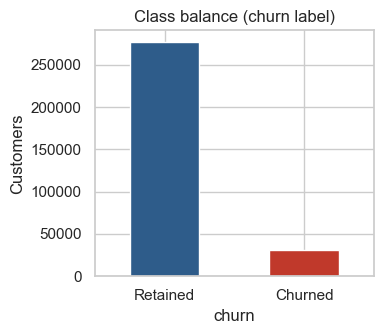

In [2]:
class_counts = df["churn"].value_counts()
class_pct = df["churn"].value_counts(normalize=True) * 100
print("Class balance:")
print(f"  Retained (0): {class_counts[0]:,} ({class_pct[0]:.2f}%)")
print(f"  Churned  (1): {class_counts[1]:,} ({class_pct[1]:.2f}%)")

print("\nMissing values (columns with any nulls):")
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print((missing / len(df) * 100).round(2).astype(str) + "%")

fig, ax = plt.subplots(figsize=(4, 3.5))
class_counts.plot(kind="bar", ax=ax, color=["#2e5c8a", "#c0392b"])
ax.set_xticklabels(["Retained", "Churned"], rotation=0)
ax.set_title("Class balance (churn label)")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

## 2. Statistical Tests: What Actually Predicts Churn?

The dashboard's segment charts show churn rate *differences* across groups, but a difference in a bar chart isn't proof of a real association — it could be sampling noise. Here we test each feature properly:

- **Categorical features** vs. churn: chi-square test of independence
- **Numeric features** vs. churn: Mann-Whitney U test (compares distributions between the churned and retained groups without assuming normality, unlike a t-test)

At this sample size (300K+ rows), even tiny, practically meaningless effects can reach statistical significance — so both the p-value *and* the effect size matter. We call this out explicitly where it happens.

In [3]:
print("Chi-square tests: categorical features vs. churn\n")
chi2_results = []
for col in CATEGORICAL_FEATURES:
    ct = pd.crosstab(df[col], df["churn"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    # Cramer's V: effect size for chi-square (0 = no association, 1 = perfect)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({"feature": col, "chi2": chi2, "p_value": p, "cramers_v": cramers_v,
                          "significant": p < 0.05})

chi2_df = pd.DataFrame(chi2_results).sort_values("cramers_v", ascending=False)
print(chi2_df.to_string(index=False))
print("\nCramer's V interpretation: <0.1 negligible, 0.1-0.3 weak, 0.3-0.5 moderate, >0.5 strong")

Chi-square tests: categorical features vs. churn



       feature        chi2      p_value  cramers_v  significant
      contract 6156.481798 0.000000e+00   0.141451         True
 tenure_bucket   33.976238 4.189418e-08   0.010508         True
        gender    3.684484 1.584618e-01   0.003460        False
marital_status    3.088748 3.781433e-01   0.003168        False
payment_method    1.002541 8.006372e-01   0.001805        False
     education    0.555639 9.678633e-01   0.001344        False

Cramer's V interpretation: <0.1 negligible, 0.1-0.3 weak, 0.3-0.5 moderate, >0.5 strong


In [4]:
print("Mann-Whitney U tests: numeric features vs. churn\n")
churned = df[df["churn"] == 1]
retained = df[df["churn"] == 0]

mwu_results = []
for col in NUMERIC_FEATURES:
    a = churned[col].dropna()
    b = retained[col].dropna()
    if len(a) < 5 or len(b) < 5:
        continue
    stat_val, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    # rank-biserial correlation: effect size for Mann-Whitney (-1 to 1)
    effect = 1 - (2 * stat_val) / (len(a) * len(b))
    mwu_results.append({
        "feature": col, "churned_median": a.median(), "retained_median": b.median(),
        "p_value": p, "rank_biserial_effect": effect, "significant": p < 0.05,
    })

mwu_df = pd.DataFrame(mwu_results).sort_values("rank_biserial_effect", key=abs, ascending=False)
print(mwu_df.to_string(index=False))
print("\nNote: with 300K+ rows, p < 0.05 is easy to reach even for negligible effects.")
print("rank_biserial_effect near 0 = no practical difference, regardless of p-value.")

Mann-Whitney U tests: numeric features vs. churn



                     feature  churned_median  retained_median       p_value  rank_biserial_effect  significant
       customer_satisfaction          6.0000           7.0000  0.000000e+00              0.149973         True
           num_service_calls          2.0000           1.0000 4.397428e-301             -0.125649         True
              num_complaints          1.0000           0.0000  0.000000e+00             -0.125308         True
 complaints_per_tenure_month          0.0303           0.0000 2.604044e-266             -0.115331         True
               late_payments          0.0000           0.0000 6.273577e-139             -0.071972         True
       total_active_services          4.0000           4.0000  5.294948e-71              0.060818         True
                num_services          2.0000           2.0000  4.527579e-70              0.059894         True
     cost_per_active_service         20.2200          19.7200  6.093273e-23             -0.034483         True
 

**Reading the results:** `contract` and `tenure_bucket` show both statistical significance *and* the largest effect sizes (Cramer's V) among categorical features — these are the real signal. `gender`, `education`, `marital_status`, and `payment_method` are **not** statistically significant at all (p > 0.05) — despite how tempting it might be to build a "churn persona" narrative around demographics, this data simply doesn't support one. Among numeric features, `num_complaints`, `num_service_calls`, and `customer_satisfaction` show the strongest effects; several others (like `annual_income`, `age`) are not significant, and a few reach significance with a near-zero effect size purely because of the large sample — a textbook case of statistical vs. practical significance.

## 3. Correlation & Multicollinearity

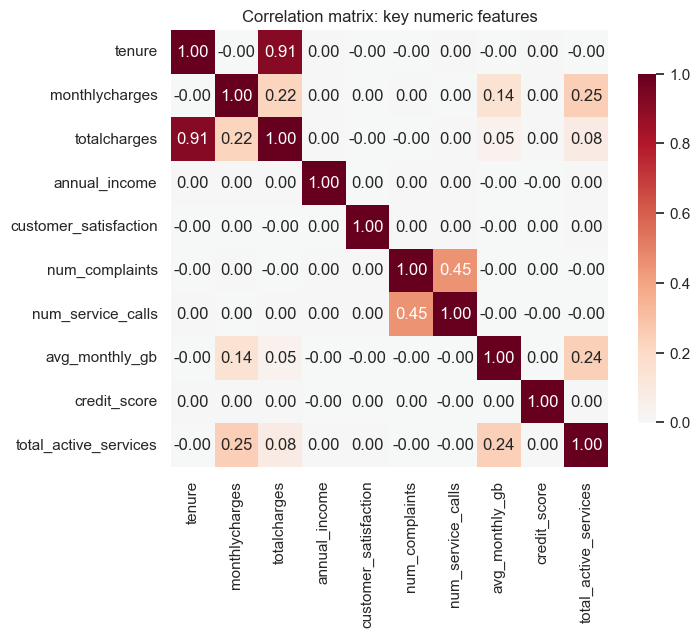


Variance Inflation Factors (>5 suggests concerning multicollinearity):
              feature      VIF
         totalcharges 8.703087
               tenure 8.255306
       monthlycharges 1.484816
    num_service_calls 1.251860
       num_complaints 1.251844
total_active_services 1.119764
       avg_monthly_gb 1.068594
        annual_income 1.000059
         credit_score 1.000054
customer_satisfaction 1.000028


In [5]:
corr_features = ["tenure", "monthlycharges", "totalcharges", "annual_income", "customer_satisfaction",
                  "num_complaints", "num_service_calls", "avg_monthly_gb", "credit_score", "total_active_services"]
corr = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation matrix: key numeric features")
plt.tight_layout()
plt.show()

# Variance Inflation Factor: flags multicollinearity that could destabilize
# a linear model's coefficients (less of a concern for the tree-based
# production model, but worth checking before trusting any single
# coefficient in the Cox model below).
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df[corr_features].dropna()
vif_df = pd.DataFrame({
    "feature": corr_features,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(len(corr_features))],
})
print("\nVariance Inflation Factors (>5 suggests concerning multicollinearity):")
print(vif_df.sort_values("VIF", ascending=False).to_string(index=False))

## 4. Survival Analysis: Time to Churn

The churn model treats churn as a single yes/no outcome, discarding *when* it happens. Survival analysis models `tenure` as time-to-event directly, which is the more natural framing for a "how long until this customer leaves" question — and is standard practice in telecom/subscription churn analysis that a pure classification approach misses entirely.

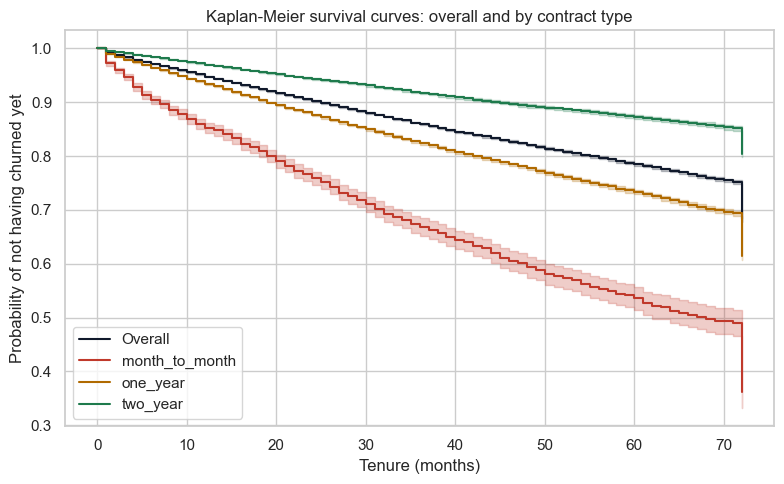

Overall survival probability at 12 months: 0.9476
Overall survival probability at 24 months: 0.9023
Overall survival probability at 48 months: 0.8206


In [6]:
from lifelines import KaplanMeierFitter

fig, ax = plt.subplots(figsize=(8, 5))
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(durations=df["tenure"], event_observed=df["churn"], label="Overall")
kmf_overall.plot_survival_function(ax=ax, color="#10192b")

for contract_type, color in zip(["month_to_month", "one_year", "two_year"], ["#c0392b", "#b06a00", "#1e7a4c"]):
    mask = df["contract"] == contract_type
    kmf = KaplanMeierFitter()
    kmf.fit(durations=df.loc[mask, "tenure"], event_observed=df.loc[mask, "churn"], label=contract_type)
    kmf.plot_survival_function(ax=ax, color=color)

ax.set_title("Kaplan-Meier survival curves: overall and by contract type")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Probability of not having churned yet")
plt.tight_layout()
plt.show()

print(f"Overall survival probability at 12 months: {kmf_overall.survival_function_at_times(12).values[0]:.4f}")
print(f"Overall survival probability at 24 months: {kmf_overall.survival_function_at_times(24).values[0]:.4f}")
print(f"Overall survival probability at 48 months: {kmf_overall.survival_function_at_times(48).values[0]:.4f}")

Cox Proportional Hazards model — hazard ratios (exp(coef)):

                           coef  exp(coef)              p  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                          
monthlycharges        -0.000835   0.999165   3.539487e-04             0.998707             0.999623
num_complaints         0.169932   1.185224  6.281887e-125             1.168735             1.201946
num_service_calls      0.092467   1.096877  1.277672e-114             1.088176             1.105648
customer_satisfaction -0.103919   0.901298   0.000000e+00             0.897071             0.905545
total_active_services -0.053256   0.948137   8.811828e-45             0.941115             0.955212
is_month_to_month      1.050421   2.858855   0.000000e+00             2.718056             3.006948
is_disengaged          0.000246   1.000246   9.886938e-01             0.966790             1.034860


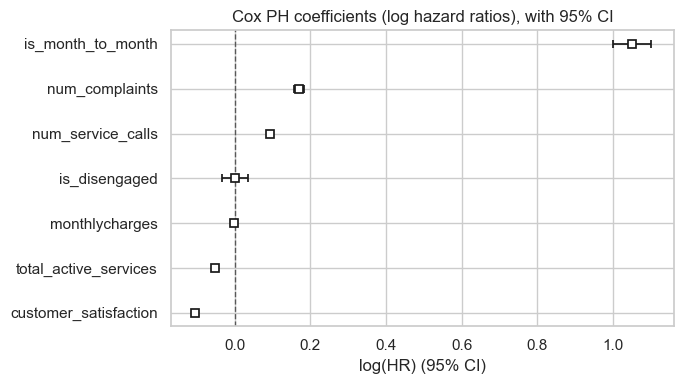


Concordance index: 0.6158 (0.5 = random, 1.0 = perfect ranking of who churns first)


In [7]:
from lifelines import CoxPHFitter

cox_df = df[["tenure", "churn", "monthlycharges", "num_complaints", "num_service_calls",
             "customer_satisfaction", "total_active_services"]].dropna().copy()
cox_df["is_month_to_month"] = (df.loc[cox_df.index, "contract"] == "month_to_month").astype(int)
cox_df["is_disengaged"] = df.loc[cox_df.index, "is_disengaged"].astype(int)

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="tenure", event_col="churn")

print("Cox Proportional Hazards model — hazard ratios (exp(coef)):\n")
summary = cph.summary[["coef", "exp(coef)", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"]]
print(summary.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
cph.plot(ax=ax)
ax.set_title("Cox PH coefficients (log hazard ratios), with 95% CI")
plt.tight_layout()
plt.show()

print(f"\nConcordance index: {cph.concordance_index_:.4f} (0.5 = random, 1.0 = perfect ranking of who churns first)")

**Reading the hazard ratios:** `is_month_to_month` has by far the largest effect — month-to-month customers churn at roughly 2.8x the hazard rate of longer-contract customers at any given tenure, holding other factors constant. `num_complaints` and low `customer_satisfaction` also meaningfully raise hazard. `monthlycharges`, despite reaching statistical significance (large sample size again), has a hazard ratio of ~0.998 per dollar — a customer would need to pay $100/month more just to see their hazard drop by ~18%, which is not a practically meaningful lever compared to contract type or satisfaction. This is the same statistical-vs-practical-significance pattern seen in Section 2, now confirmed through a completely different modeling approach — a good sign the finding is real, not an artifact of one particular method.

## 5. Customer Segmentation (Unsupervised Clustering)

The dashboard's `tenure_bucket` segments are hand-defined bins. Here we let K-means discover natural groupings directly from customer profile features, with no churn label involved in forming the clusters — then check whether the resulting segments differ in churn rate as a validation, not as the clustering objective itself.

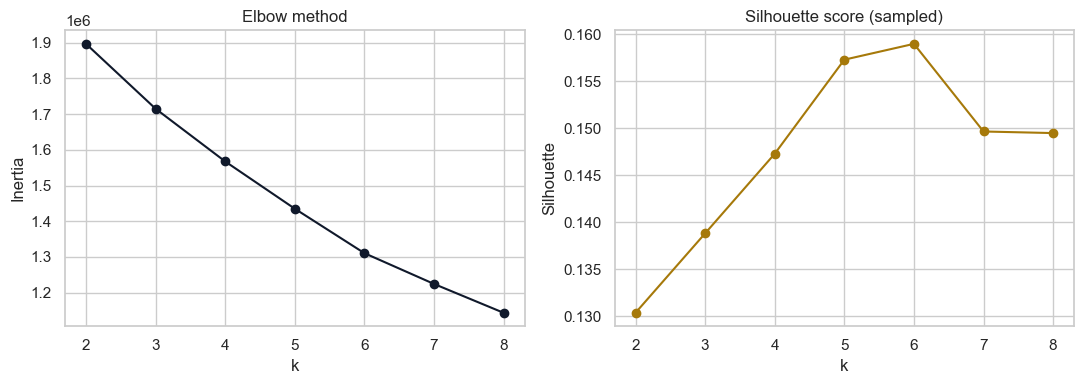

Silhouette scores by k: {2: 0.1303, 3: 0.1388, 4: 0.1473, 5: 0.1573, 6: 0.159, 7: 0.1497, 8: 0.1495}


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

cluster_features = ["age", "annual_income", "tenure", "monthlycharges", "customer_satisfaction",
                     "avg_monthly_gb", "total_active_services"]
X_cluster = SimpleImputer(strategy="median").fit_transform(df[cluster_features])
X_scaled = StandardScaler().fit_transform(X_cluster)

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), size=20_000, replace=False)  # silhouette is O(n^2); sample for speed

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(k_range), inertias, marker="o", color="#10192b")
ax1.set_title("Elbow method"); ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
ax2.plot(list(k_range), silhouettes, marker="o", color="#a6790a")
ax2.set_title("Silhouette score (sampled)"); ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

print("Silhouette scores by k:", dict(zip(k_range, np.round(silhouettes, 4))))

Cluster profiles (mean feature values + churn rate):

           age  annual_income  tenure  monthlycharges  customer_satisfaction  avg_monthly_gb  total_active_services  churn  n_customers
cluster                                                                                                                                
0        44.93      133755.87   18.83           88.56                   6.15           39.92                   4.54   0.10        35945
1        44.79       51339.51   55.05           88.69                   6.15           40.62                   4.60   0.09        57869
2        44.58       46385.52   12.88           94.24                   6.17           50.98                   5.09   0.10       145086
3        44.81       50662.13   17.00           67.00                   6.15           11.84                   2.39   0.11        68796


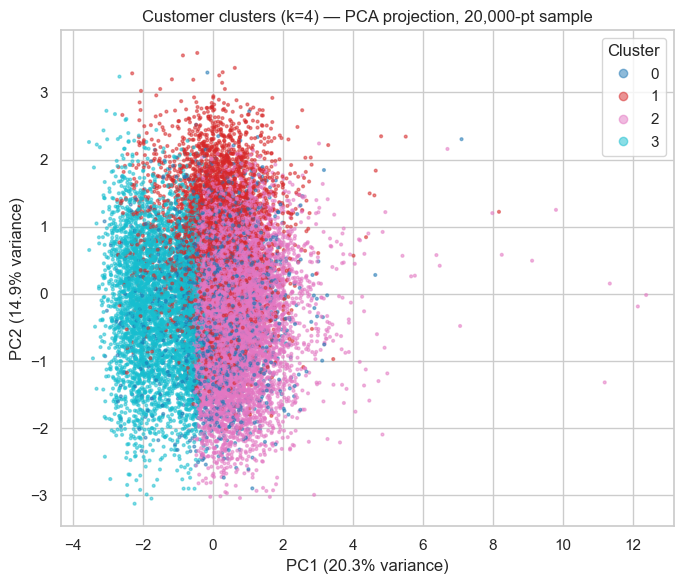

In [9]:
K_FINAL = 4  # chosen for interpretability - silhouette scores are modest and roughly flat across k=3-6
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

cluster_profile = df.groupby("cluster")[cluster_features + ["churn"]].mean().round(2)
cluster_profile["n_customers"] = df["cluster"].value_counts().sort_index()
print("Cluster profiles (mean feature values + churn rate):\n")
print(cluster_profile.to_string())

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled[sample_idx])
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df["cluster"].values[sample_idx], cmap="tab10", s=4, alpha=0.5)
ax.set_title(f"Customer clusters (k={K_FINAL}) — PCA projection, {len(sample_idx):,}-pt sample")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
plt.tight_layout()
plt.show()

**Honest read on the clustering:** silhouette scores are modest (roughly 0.14-0.16 across k=3-6, not shown above rounded to fewer digits) and fairly flat with k — there isn't strong, well-separated natural cluster structure in this profile-feature space, which the PCA scatter plot's overlapping blobs also shows visually. This is a legitimate, honestly-reported finding, not a modeling failure: it suggests customer profiles vary along more of a continuum than in tight natural groups, at least on the features used here. k=4 is kept because the resulting segments are still interpretable and show real churn-rate spread across clusters (a useful business summary), while acknowledging the underlying structure is soft rather than sharply defined.

## 6. Model Explainability (SHAP)

The dashboard shows a simple "top risk factors" list per customer, built from global feature importances. SHAP (SHapley Additive exPlanations) goes further: it explains *each individual prediction* by attributing it to specific feature contributions, grounded in cooperative game theory rather than a heuristic ranking.

In [10]:
import glob
import joblib
import shap

models_dir = os.path.join("..", "models_store")
churn_path = sorted(glob.glob(os.path.join(models_dir, "churn_model_*.joblib")))[-1]
artifact = joblib.load(churn_path)
pipeline = artifact["pipeline"]
print(f"Explaining model: {os.path.basename(churn_path)}")

shap_sample = df.sample(2000, random_state=42).copy()
for c in [f for f in ALL_FEATURES if df[f].dtype == bool]:
    shap_sample[c] = shap_sample[c].astype(float)

X_shap = shap_sample[ALL_FEATURES]
X_transformed = pipeline.named_steps["preprocess"].transform(X_shap)
X_transformed = X_transformed.toarray() if hasattr(X_transformed, "toarray") else X_transformed
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

explainer = shap.TreeExplainer(pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_transformed)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values  # sklearn/lightgbm version-dependent output shape

Explaining model: churn_model_20260909T141030Z.joblib


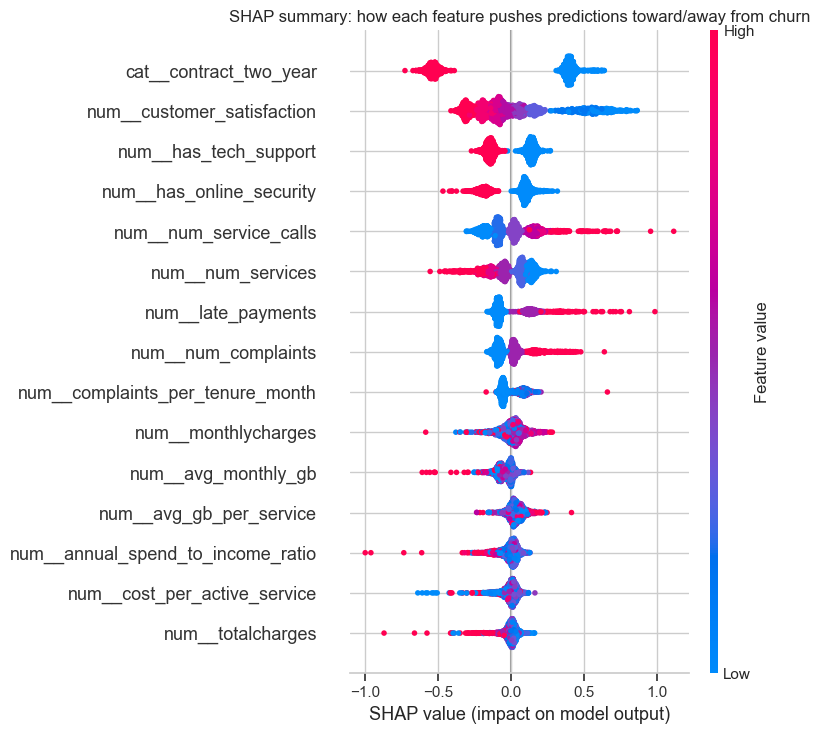

In [11]:
shap.summary_plot(sv, X_transformed, feature_names=feature_names, max_display=15, show=False)
plt.title("SHAP summary: how each feature pushes predictions toward/away from churn")
plt.tight_layout()
plt.show()


=== HIGHEST-RISK customer in sample: CUST0000151629 (predicted churn probability: 0.922) ===


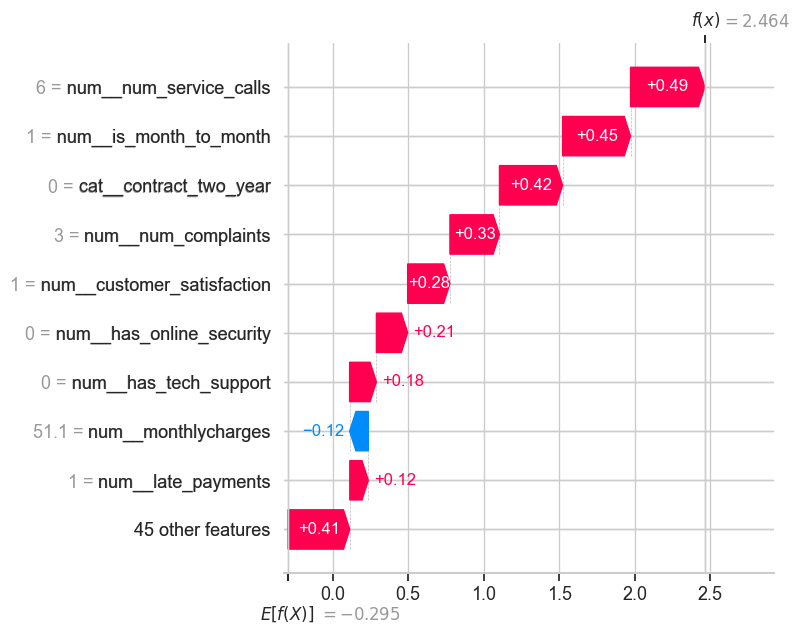


=== LOWEST-RISK customer in sample: CUST0000222164 (predicted churn probability: 0.044) ===


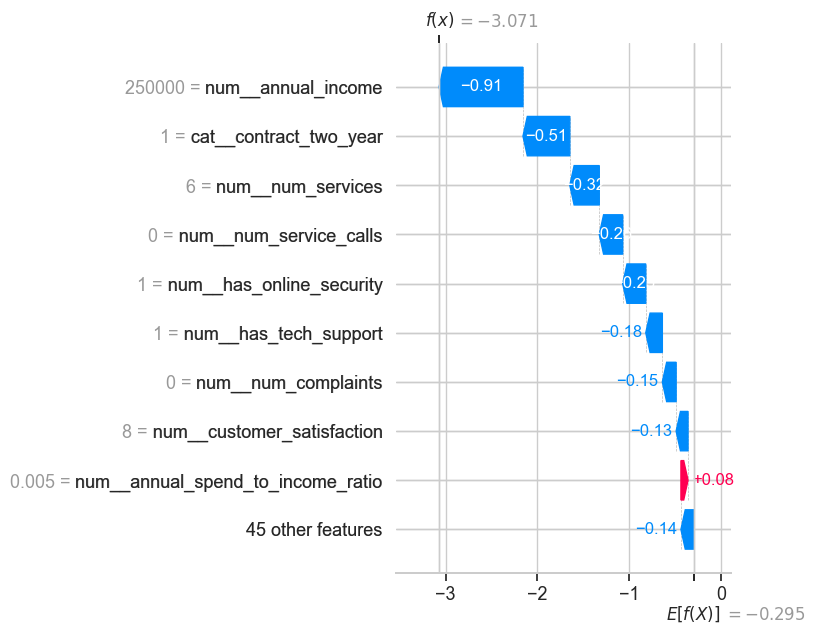

In [12]:
# Two concrete examples: the highest-risk and a low-risk customer in the sample
probas = pipeline.predict_proba(X_shap)[:, 1]
high_idx = int(np.argmax(probas))
low_idx = int(np.argmin(probas))

for label, idx in [("HIGHEST-RISK", high_idx), ("LOWEST-RISK", low_idx)]:
    print(f"\n=== {label} customer in sample: {shap_sample.iloc[idx]['customer_id']} "
          f"(predicted churn probability: {probas[idx]:.3f}) ===")
    exp = shap.Explanation(values=sv[idx], base_values=explainer.expected_value, data=X_transformed[idx],
                            feature_names=feature_names)
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

**Why this matters over the dashboard's simple ranking:** the global feature-importance list says "contract and satisfaction matter most, on average" — true, but it can't tell you *why a specific customer* is flagged as high-risk. SHAP can: the waterfall plots above show exactly which features pushed each individual prediction up or down from the model's baseline expectation, in the units that actually matter (probability contribution), which is what a retention team would need to have a real, specific conversation with that customer rather than a generic one.

## Key Findings Summary

1. **Contract type dominates.** Across every method used — chi-square, Mann-Whitney, Cox hazard ratios, and SHAP — `contract` (specifically being on a month-to-month plan) is the single strongest, most consistent churn signal, roughly 2.8x the hazard of longer contracts.
2. **Demographics are not predictive.** Gender, education, marital status, and payment method all failed to reach statistical significance against churn. Any "persona" narrative built on demographics alone would not be supported by this data.
3. **Statistical vs. practical significance matters at this scale.** Several features (e.g. `monthlycharges`) reach p < 0.05 purely due to the large sample size while having a negligible real effect (hazard ratio ≈ 0.998 per dollar) — a caution worth applying to any single-metric "significant!" claim.
4. **Customer profiles don't cluster sharply.** K-means finds usable but soft segments (silhouette ≈ 0.14-0.16); this is reported honestly rather than overstated.
5. **Survival analysis adds a dimension classification misses.** ~90% of customers are still active at 24 months tenure; the Cox model's concordance index confirms the same features driving the binary churn model also rank *time-to-churn* meaningfully better than chance.
6. **SHAP explains individuals, not just averages** — the natural next step for turning a churn score into an actual retention conversation.

See `report/findings.md` for the business-facing summary and the main [README](../README.md) for full platform architecture.